# **I. Model Development Introduction**

## 1. **What is a Model?**
* **Definition:** A model (or estimator) is a mathematical equation used to predict a value given one or more other values.
* **Mechanism:** It relates one or more **independent variables** (features/inputs) to a **dependent variable** (the output/target).
* **Example:** Using a car's `highway-mpg` (independent variable) to predict its `price` (dependent variable).

## 2. **The Importance of Data**
* **General Rule:** Usually, the more relevant data (features) you input into your model, the more accurate your predictions will be.
* **The "Pink Car" Example:** If you have two identical cars, but one is red and one is pink (which sells for less), **a model lacking `color` as an independent variable will inaccurately predict the exact same price for both.**

## 3. **Topics Covered in this Module**
* Simple and Multiple Linear Regression.
* Polynomial Regression and Pipelines.
* Model evaluation using visualization.
* R-squared and Mean Squared Error (MSE) for in-sample evaluation.
* Prediction, decision making, and determining a fair value for a used car.

---
# **II. Hồi quy Tuyến tính (Linear Regression)**

## 1. **Hồi quy Tuyến tính Đơn giản (Simple Linear Regression - SLR)**
* **Định nghĩa:** Phương pháp sử dụng **1 biến độc lập** ($x$) để dự đoán **1 biến phụ thuộc** ($y$).
* **Công thức toán học:** 
  $$\hat{y} = b_0 + b_1x$$
  * $\hat{y}$: Giá trị dự đoán (ước lượng).
  * $b_0$: Điểm giao cắt trục tung (Intercept).
  * $b_1$: Độ dốc (Slope).
* **Nhiễu (Noise):** Có một sự sai lệch nhỏ ngẫu nhiên cộng thêm vào các điểm dữ liệu thực tế so với đường hồi quy lý tưởng. Nếu giả định tuyến tính là đúng, sai số giữa giá trị thực tế và giá trị dự đoán chủ yếu đến từ nhiễu này.

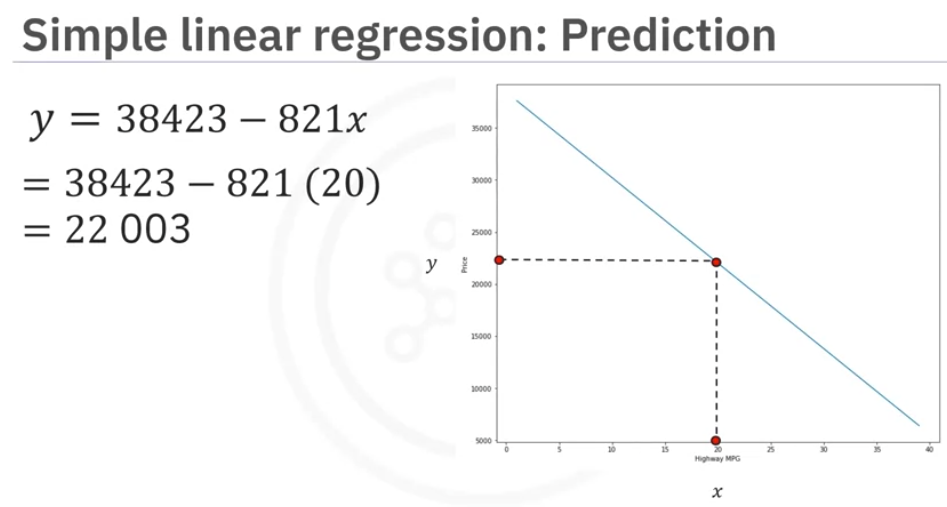
## 2. **Hồi quy Tuyến tính Bội (Multiple Linear Regression - MLR)**
* **Định nghĩa:** Sử dụng **nhiều biến độc lập** ($x_1, x_2, \dots, x_n$) để giải thích mối quan hệ với **1 biến phụ thuộc liên tục** ($y$).
* **Công thức toán học:**
  $$\hat{y} = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n$$
  * $b_0$: Intercept (Giá trị của $\hat{y}$ khi tất cả các $x = 0$).
  * $b_1, b_2, \dots, b_n$: Các hệ số (Coefficients / Parameters) thể hiện trọng số tác động của từng biến $x$.
* **Trực quan hóa:** Nếu có 2 biến độc lập ($x_1, x_2$), dữ liệu có thể được ánh xạ trên một mặt phẳng tọa độ 2D, với $\hat{y}$ là chiều cao dọc theo trục thẳng đứng tương ứng.

## 3. **Triển khai mô hình trong Python (scikit-learn)**
* **Khởi tạo:** `lm = LinearRegression()`
* **Huấn luyện (Training):** Dùng `lm.fit(X, y)` để đưa các điểm dữ liệu vào máy học nhằm tìm ra các tham số lý tưởng ($b_0$, $b_1$,...).
* **Dự đoán (Prediction):** Dùng `lm.predict(X)` để xuất ra mảng kết quả $\hat{y}$ cho các mẫu dữ liệu chưa biết.
* **Trích xuất các tham số:** 
  * Lấy $b_0$: `lm.intercept_`
  * Lấy mảng các $b_1, b_2, \dots$: `lm.coef_`

In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Tạo DataFrame giả lập dữ liệu xe
df = pd.DataFrame({
    'highway_mpg': [20, 25, 30, 35, 40],
    'engine_size': [130, 110, 90, 80, 70],
    'horsepower': [111, 100, 80, 75, 60],
    'price': [22000, 18000, 15000, 12000, 10000]
})

print("==== DỮ LIỆU HUẤN LUYỆN (TRAINING DATA) ====")
print(df)
print("\n")

# --- VÍ DỤ 1: SIMPLE LINEAR REGRESSION ---
print("==== 1. SIMPLE LINEAR REGRESSION (SLR) ====")
lm_slr = LinearRegression()

# Biến độc lập (X) phải là mảng 2 chiều (DataFrame)
X_slr = df[['highway_mpg']]
Y = df['price']

# Huấn luyện mô hình
lm_slr.fit(X_slr, Y)
b0_slr = lm_slr.intercept_
b1_slr = lm_slr.coef_[0]

print(f"Phương trình SLR: Giá xe (Price) = {b0_slr:.2f} + ({b1_slr:.2f}) * highway_mpg")
# Dự đoán với dữ liệu không nằm trong tập huấn luyện
print(f"Dự đoán giá cho xe có highway_mpg = 22: ${lm_slr.predict([[22]])[0]:.2f}")
print("\n")

# --- VÍ DỤ 2: MULTIPLE LINEAR REGRESSION ---
print("==== 2. MULTIPLE LINEAR REGRESSION (MLR) ====")
lm_mlr = LinearRegression()

# Lấy 3 biến độc lập để đưa vào Z
Z = df[['highway_mpg', 'engine_size', 'horsepower']]

# Huấn luyện mô hình với nhiều biến
lm_mlr.fit(Z, Y)
b0_mlr = lm_mlr.intercept_
b_coefs = lm_mlr.coef_

print(f"Intercept (b0): {b0_mlr:.2f}")
print(f"Coefficients (b1, b2, b3): {b_coefs}")
print(f"Phương trình MLR: Price = {b0_mlr:.2f} + ({b_coefs[0]:.2f}*highway_mpg) + ({b_coefs[1]:.2f}*engine_size) + ({b_coefs[2]:.2f}*horsepower)")

# Dự đoán một mẫu mới chứa cả 3 thuộc tính
sample_predict = lm_mlr.predict([[22, 120, 105]])
print(f"Dự đoán giá cho mẫu mới: ${sample_predict[0]:.2f}")

==== DỮ LIỆU HUẤN LUYỆN (TRAINING DATA) ====
   highway_mpg  engine_size  horsepower  price
0           20          130         111  22000
1           25          110         100  18000
2           30           90          80  15000
3           35           80          75  12000
4           40           70          60  10000


==== 1. SIMPLE LINEAR REGRESSION (SLR) ====
Phương trình SLR: Giá xe (Price) = 33400.00 + (-600.00) * highway_mpg
Dự đoán giá cho xe có highway_mpg = 22: $20200.00


==== 2. MULTIPLE LINEAR REGRESSION (MLR) ====
Intercept (b0): 20986.75
Coefficients (b1, b2, b3): [-393.15673289  157.72626932 -104.85651214]
Phương trình MLR: Price = 20986.75 + (-393.16*highway_mpg) + (157.73*engine_size) + (-104.86*horsepower)
Dự đoán giá cho mẫu mới: $20254.53


c:\env-related\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\env-related\Python314\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---
# **III. Model Evaluation using Visualization**

## 1. **Regression Plots**
* **Purpose:** Provides a good estimate of the relationship between two variables, the strength of the correlation, and the direction of the relationship (positive or negative).
* **Structure:**
  * Horizontal axis (x): Independent variable (feature).
  * Vertical axis (y): Dependent variable (target).
  * Points: Actual target values.
  * Fitted line: Predicted values.
* **Implementation:** `seaborn.regplot(x="feature", y="target", data=df)`

## 2. **Residual Plots**
* **Definition:** Represents the error between the actual target value and the predicted value.
* **Mathematical Formula:** 
  $$e = y - \hat{y}$$
  *(Where $y$ is the actual value and $\hat{y}$ is the predicted value).*
* **Model Evaluation:**
  * **Ideal Linear Model:** The residuals have zero mean, are distributed evenly around the x-axis with similar variance, and show no curvature.
  * **Incorrect Model Indicators:**
    * Curvature present: Suggests a nonlinear function is appropriate.
    * Variance changes with $x$: The linear assumption is incorrect.
* **Implementation:** `seaborn.residplot(x=feature_series, y=target_series)`

## 3. **Distribution Plots**
* **Purpose:** Compares the distribution of the predicted values against the actual values. Extremely useful for visualizing models with more than one independent variable (Multiple Linear Regression).
* **Mechanism:** Since target and predicted values are continuous, they are converted into a distribution rather than a discrete histogram. The vertical axis is scaled so the area under the curve equals 1.
* **Implementation:** Plot both the actual and fitted continuous values on the same chart (e.g., using `sns.kdeplot`) to visually inspect which price ranges the model predicts accurately.

==== SIMULATED DATA ====
   highway_mpg  price  predicted_price
0           20  22000            21500
1           25  18000            18500
2           30  15000            14500
3           35  12000            12500
4           40  10000             9500




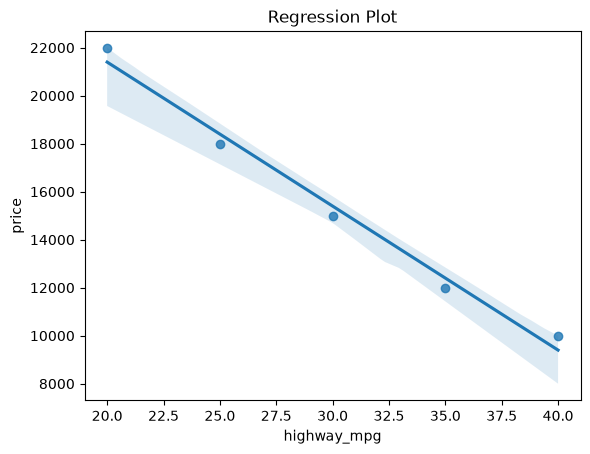

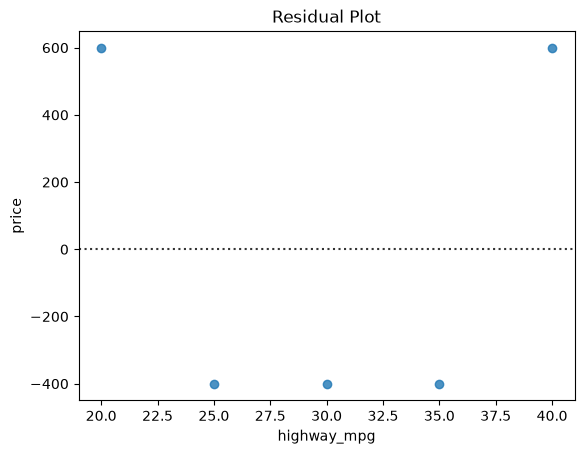

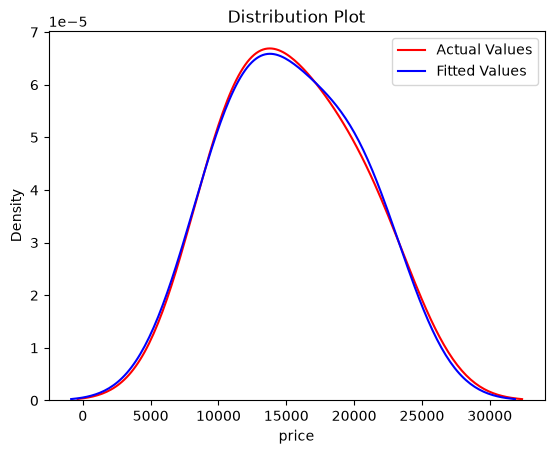

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create simulated dataframe with actual vs predicted values
df = pd.DataFrame({
    'highway_mpg': [20, 25, 30, 35, 40],
    'price': [22000, 18000, 15000, 12000, 10000],
    'predicted_price': [21500, 18500, 14500, 12500, 9500] 
})

print("==== SIMULATED DATA ====")
print(df)
print("\n")

# ==== VISUALIZATION COMMANDS ====

# 1. Regression Plot
plt.figure()
sns.regplot(x='highway_mpg', y='price', data=df)
plt.title('Regression Plot')

# 2. Residual Plot
plt.figure()
sns.residplot(x=df['highway_mpg'], y=df['price'])
plt.title('Residual Plot')

# 3. Distribution Plot
plt.figure()
sns.kdeplot(df['price'], color='red', label='Actual Values')
sns.kdeplot(df['predicted_price'], color='blue', label='Fitted Values')
plt.title('Distribution Plot')
plt.legend()

plt.show()

---
# **IV. Polynomial Regression and Pipelines**

## 1. **Polynomial Regression**
* **Purpose:** Used when a linear model is not the best fit for the data. It transforms data into a polynomial to describe curvilinear relationships, then uses linear regression to fit the parameters.
* **Types of Models:**
  * **Quadratic (2nd order):** The predictor variable is squared ($x^2$).
  * **Cubic (3rd order):** The predictor variable is cubed ($x^3$).
  * Higher-order polynomials are used if 2nd or 3rd order do not provide a good fit.
* **Key Note:** Even though the features have exponents, the relationship between the *parameters* (coefficients) and the output is still linear.
* **1D Polynomials:** Can be fitted using NumPy's `polyfit` function.
* **Multi-dimensional Polynomials:** Handled using `PolynomialFeatures` from `scikit-learn`'s preprocessing library.

## 2. **Data Normalization**
* When dealing with larger dimensions and higher-order polynomials, normalizing features is often necessary.
* **Standardization:** Using `StandardScaler` from `scikit-learn` to standardize each feature simultaneously via `fit` and `transform` methods.

## 3. **Pipelines**
* **Purpose:** Simplifies code by sequentially performing a series of transformations (e.g., scaling $\rightarrow$ polynomial transform $\rightarrow$ linear regression) in a single, clean workflow.
* **Implementation:** 
  * Import `Pipeline` from `sklearn.pipeline`.
  * Create a list of tuples, where each tuple contains the name of the estimator and the model constructor (e.g., `('scale', StandardScaler())`).
  * Pass the list into the `Pipeline` constructor.
  * Train the entire pipeline using `.fit()`.
  * Generate predictions with `.predict()`, which automatically applies all intermediate transformations to the input data before outputting the result.

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Create simulated dataframe
df = pd.DataFrame({
    'highway_mpg': [20, 25, 30, 35, 40],
    'engine_size': [130, 110, 90, 80, 70],
    'price': [30000, 22000, 16000, 11000, 9000]
})

print("==== SIMULATED DATA ====")
print(df)
print("\n")

# --- Example 1: 1D Polynomial Regression with NumPy ---
print("==== 1. 1D POLYNOMIAL REGRESSION (NumPy) ====")
x = df['highway_mpg']
y = df['price']

# Fit a 3rd order polynomial
f_3rd = np.polyfit(x, y, 3)
p_3rd = np.poly1d(f_3rd)
print("3rd Order Polynomial Equation:")
print(p_3rd)
print("\n")

# --- Example 2: Multidimensional Polynomial & Pipeline (Scikit-Learn) ---
print("==== 2. PIPELINES & MULTI-DIMENSIONAL POLYNOMIALS ====")

# Create the list of tuples outlining the sequence of operations
Input = [
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
]

# Construct the pipeline
pipe = Pipeline(Input)

# Train the entire pipeline at once using multiple features
Z = df[['highway_mpg', 'engine_size']]
pipe.fit(Z, y)

# Predict using the trained pipeline (automatically scales and transforms first)
predictions = pipe.predict(Z)
print("Pipeline Predictions (Scale -> Poly(2) -> LinReg):")
print(predictions)

==== SIMULATED DATA ====
   highway_mpg  engine_size  price
0           20          130  30000
1           25          110  22000
2           30           90  16000
3           35           80  11000
4           40           70   9000


==== 1. 1D POLYNOMIAL REGRESSION (NumPy) ====
3rd Order Polynomial Equation:
        3         2
0.6667 x - 22.86 x - 1545 x + 6.467e+04


==== 2. PIPELINES & MULTI-DIMENSIONAL POLYNOMIALS ====
Pipeline Predictions (Scale -> Poly(2) -> LinReg):
[30000. 22000. 16000. 11000.  9000.]
